In [32]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import time


Loading BokehJS ...

# Funciones básicas

In [2]:
    # Obtenemos la solución clásica por fuerza bruta
    def resolucion_clasica(Q_exacta, print_resultados = False):
        """
        Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO.
        verbose : bool       – Si True, imprime las mejores soluciones.

        Retorna
        -------
        sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
        """
        Q_exacta = np.array(Q_exacta)

        bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
        costs = []
        
        for b in bitstrings:
            z = np.array(list(b), dtype=int)
            cost = z @ Q_exacta @ z
            costs.append(cost)
        zipped = zip(bitstrings, costs)
        sort_zipped = sorted(zipped, key=lambda x: x[1])

        if print_resultados:
            print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

        return sort_zipped
    # Ejecución de la función 
    #sort_zipped = resolucion_clasica(Q_exacta)


    # Determinamos la geometría de los átomos para Q
    def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
        """
        Optimiza las coordenadas atómicas para que las interacciones Rydberg
        reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO (simétrica).
        seed    : int        – Semilla para reproducibilidad.
        tol     : float      – Tolerancia del optimizador Nelder-Mead.
        maxiter : int        – Máximo de iteraciones.
        plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

        Retorna
        -------
        geometria : bloqade Program – Geometría lista para montar el programa.
        coords    : np.ndarray      – Coordenadas optimizadas (n×2).
        """
        Q = np.array(Q)
        device = pulser.DigitalAnalogDevice

        def evaluate_mapping(new_coords):
            new_coords = np.reshape(new_coords, (len(Q), 2))
            new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
            return np.linalg.norm(new_Q - Q)

        # Por si queremos cambiar el x0:
        if x0_func is not None:
            x0 = x0_func(A, Q)
        else:
            np.random.seed(seed)
            x0 = np.random.random(len(Q) * 2)

        #if random_x0 == True:
        #    np.random.seed(seed)
        #    x0 = np.random.random(len(Q) * 2)
        #elif random_x0 == False:
        #    C6 = 2 * np.pi * 862690
        #    d_init = (C6 / A) ** (1/6)
        #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

        res = minimize(
            evaluate_mapping,
            x0,
            method="Nelder-Mead",
            tol=tol,
            options={"maxiter": maxiter, "maxfev": None},
        )

        coords = np.reshape(res.x, (len(Q), 2))

        if plot:
            # Visualización Pulser
            #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
            #reg = pulser.Register(coord_dict)
            #reg.draw(
            #    blockade_radius=device.rydberg_blockade_radius(1),
            #    draw_graph=False,
            #    draw_half_radius=True,
            #)
            coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
            reg = pulser.Register(coord_dict)
            # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
            omega_max = 0.9 * np.min(-np.diag(Q))
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(omega_max),
                draw_graph=False,
                draw_half_radius=True,
            )
            print(f"Coordenadas optimizadas:\n{coords}")

        # Construcción Bloqade
        coordenadas = [tuple(pt) for pt in coords.tolist()]
        geometria = start.add_position(coordenadas)

        if plot:
            geometria.show()

        return geometria, coords
    # Ejecución de la función 
    #geometria, coords = construir_geometria(Q)


    def resolver_qubo(Q, geometria, sort_zipped, A, B, C=0,
                        sweep_time=11.0, plot=False, n_shots=1000):
        """
        Ejecuta la simulación de átomos neutros para un problema QUBO dado.

        Parámetros
        ----------
        Q             : array-like  – Matriz QUBO.
        geometria     : Register     – Geometría de átomos (Bloqade).
        sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
        A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
        omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.
        n_shots       : int          – Número de disparos de la simulación.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.

        Retorna
        -------
        prob_exito    : float        – Probabilidad de medir la solución correcta.
        counts_str    : dict         – {bitstring: conteos}.
        """
        # ── PASO 1: Detunings locales desde la diagonal de Q ──
        Q = np.array(Q)
        delta_local = -np.diag(Q)
        delta_end   = np.max(delta_local)
        escalas     = (delta_local / delta_end).tolist()

        # ── PASO 2: Parámetros de pulso ──
        omega_max = 0.9 * np.min(np.abs(delta_local))
        sweep_time= sweep_time
        durations             = [0.8, sweep_time, 0.8]
        rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
        rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

        # ── PASO 3: Simulación ──
        prog = (
            geometria
            .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
            .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
        )
        emu_prog = prog.bloqade.python().run(shots=n_shots)
        report   = emu_prog.report()
        if plot:
            report.show()


        # ── PASO 4: Análisis ──
        counts = report.counts()[0]
        counts_str = {
            "".join(str(b) for b in estado): n
            for estado, n in counts.items()
        }

        energia_minima   = sort_zipped[0][1]
        soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

        exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
        prob_exito = exitos / n_shots

        # ── PASO 5: Resultados ──
        if plot:
            print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
            print(f"  Conteos solución:   {exitos} / {n_shots}")
            counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
            colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
            plt.figure(figsize=(12, 5))
            plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
            plt.xlabel("Bitstrings")
            plt.ylabel("Conteos")
            plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            plt.xticks(rotation=90, fontsize=7)
            plt.tight_layout()
            plt.show()

        return prob_exito, counts_str
    # Ejecución de la función 
    #prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Grafos que "fallan" ($P_7$, $C_6$)

In [3]:
Q_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0,      0     ],
    [0,       0,     0,    -3*B+C,  A+2*B,  0     ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B ],
    [0,       0,     0,     0,      0,     -2*B+C ]
])
Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B,      0     ],
    [0,       0,     0,    -3*B+C,  A+2*B,  B     ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B ],
    [0,       0,     0,     0,      0,     -2*B+C ]
])
def x0_func_P7(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0], [5*d, 0.0],
    ]).flatten()




Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0,      0    ],
    [0,       0,    -3*B+C, A+2*B,  0,      0    ],
    [0,       0,     0,    -3*B+C,  A+2*B,  0    ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B],
    [0,       0,     0,     0,      0,     -3*B+C]
])
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      0,      B    ],
    [0,       0,    -3*B+C, A+2*B,  B,      0    ],
    [0,       0,     0,    -3*B+C,  A+2*B,  B    ],
    [0,       0,     0,     0,     -3*B+C,  A+2*B],
    [0,       0,     0,     0,      0,     -3*B+C]
])
def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/6)) = d
    R = d / (2 * np.sin(np.pi / 6))
    return np.array([
        [R * np.cos(2*np.pi*k/6 + np.pi/2), R * np.sin(2*np.pi*k/6 + np.pi/2)]
        for k in range(6)
    ]).flatten()

# Grafos

In [4]:
Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,       B],
    [0,      -3*B+C,  A+2*B],
    [0,       0,     -2*B+C]
])
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0     ],
    [0,      -3*B+C, A+2*B, B     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0],
    ]).flatten()


Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()


Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()


Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B], 
    [0,      -3*B+C, A+2*B, 0,     0    ],  
    [0,       0,    -3*B+C, A+2*B, 0    ],  
    [0,       0,     0,    -4*B+C, A+2*B],  
    [0,       0,     0,     0,    -3*B+C],  
])
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
def x0_func_C4mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [ 0.0,             0.0 ],
        [ d,               0.0 ],
        [ d,               d   ],
        [ 0.0,             d   ],
        [-d*np.sqrt(3)/2,  d/2 ],
    ]).flatten()


Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()


Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
def x0_func_C5mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 = (4,5) en triángulo equilátero con x_3=(3,4) y x_4=(4,0)
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()


Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

# Energías exacta/truncada

In [5]:
grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    "C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
    "K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal)
}

import sympy as sp

A_s, B_s, C_s = sp.symbols('A B C', positive=True)

# Valores numéricos para ordenar
A_num, B_num, C_num = 50, 0.7*50, 0.35*50

for nombre, (Q_func_g, Q_exacta_func_g, _) in grafos.items():
    Q_trunc = Q_func_g(A_s, B_s, C_s)
    Q_exacta = Q_exacta_func_g(A_s, B_s, C_s)
    N = len(Q_trunc)

    bitstrings = [np.binary_repr(i, N) for i in range(2**N)]

    energias_trunc = []
    energias_exacta = []
    for b in bitstrings:
        z = np.array(list(b), dtype=int)
        e_t = sp.simplify(z @ Q_trunc @ z)
        e_e = sp.simplify(z @ Q_exacta @ z)
        energias_trunc.append((b, e_t))
        energias_exacta.append((b, e_e))

    subs = {A_s: A_num, B_s: B_num, C_s: C_num}
    energias_trunc.sort(key=lambda x: float(x[1].subs(subs)))
    energias_exacta.sort(key=lambda x: float(x[1].subs(subs)))

    coincide = "✓" if energias_exacta[0][0] == energias_trunc[0][0] else "✗"

    print(f"--- {nombre} (N={N}) --- ¿Coincide GS? {coincide}")
    for i in range(min(5, len(energias_exacta))):
        be, ee = energias_exacta[i]
        bt, et = energias_trunc[i]
        label = "GS" if i == 0 else f"E{i}"
        print(f"  {label}  Exacta: {be} E={ee}   |  Truncada: {bt} E={et}")
    print()


--- P3 (N=2) --- ¿Coincide GS? ✓
  GS  Exacta: 01 E=-2*B + C   |  Truncada: 01 E=-2*B + C
  E1  Exacta: 10 E=-2*B + C   |  Truncada: 10 E=-2*B + C
  E2  Exacta: 00 E=0   |  Truncada: 00 E=0
  E3  Exacta: 11 E=A - 2*B + 2*C   |  Truncada: 11 E=A - 2*B + 2*C

--- P4 (N=3) --- ¿Coincide GS? ✗
  GS  Exacta: 010 E=-3*B + C   |  Truncada: 101 E=-4*B + 2*C
  E1  Exacta: 101 E=-3*B + 2*C   |  Truncada: 010 E=-3*B + C
  E2  Exacta: 001 E=-2*B + C   |  Truncada: 001 E=-2*B + C
  E3  Exacta: 100 E=-2*B + C   |  Truncada: 100 E=-2*B + C
  E4  Exacta: 011 E=A - 3*B + 2*C   |  Truncada: 011 E=A - 3*B + 2*C

--- P5 (N=4) --- ¿Coincide GS? ✓
  GS  Exacta: 0101 E=-4*B + 2*C   |  Truncada: 0101 E=-5*B + 2*C
  E1  Exacta: 1001 E=-4*B + 2*C   |  Truncada: 1010 E=-5*B + 2*C
  E2  Exacta: 1010 E=-4*B + 2*C   |  Truncada: 1001 E=-4*B + 2*C
  E3  Exacta: 0010 E=-3*B + C   |  Truncada: 0010 E=-3*B + C
  E4  Exacta: 0100 E=-3*B + C   |  Truncada: 0100 E=-3*B + C

--- P6 (N=5) --- ¿Coincide GS? ✗
  GS  Exacta: 0

# Resolución 1 caso

---Solución clásica: 
 [('001', np.float64(-130.0)), ('010', np.float64(-130.0)), ('100', np.float64(-130.0)), ('011', np.float64(-120.0)), ('101', np.float64(-120.0)), ('110', np.float64(-120.0))] 



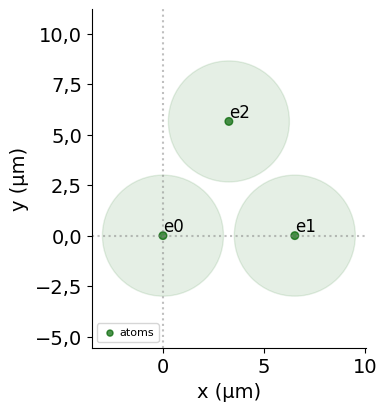

Coordenadas optimizadas:
[[3.26590818e-04 1.72677645e-04]
 [6.52891032e+00 3.61146341e-04]
 [3.26445566e+00 5.65418649e+00]]


326.5908179905518 6528910.315073354 172.67764529513994 5654186.491677436


A=50, B=45.0, C=5.0  →  P(éxito) = 78.30%
  Soluciones válidas: ['001', '010', '100']  (E = -130.000)
  Conteos solución:   783 / 1000


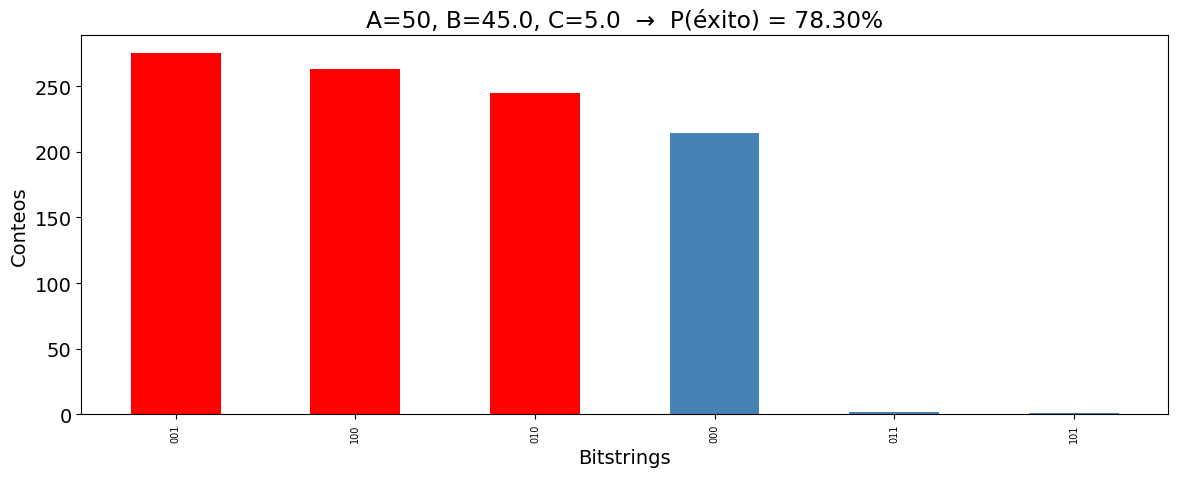

In [31]:
for k in [1]:
    A = A_solucion = 50#= 50 #= 10
    B = B_solucion = 0.9*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.1*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion
    Q_exacta_func = Q_exacta_func_K13
    Q_func = Q_func_K13
    x0_func = x0_func_K13

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True)

    A_values = [A]
    B_values = [B]
    C_values = [C]

# Comprobación tiempo ejecución-tiempo de barrido

In [27]:
import time

for k in [0.5, 1.5, 4.5, 13.5]:          # ← aquí los valores de T_barrido
    t0 = time.time()           # cronómetro de esta ejecución

    A = A_solucion = 50#= 50 #= 10
    B = B_solucion = 0.9*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.1*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion
    Q_exacta_func = Q_exacta_func_K13
    Q_func = Q_func_K13
    x0_func = x0_func_K13

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=False, x0_func=x0_func)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, sweep_time=k)

    A_values = [A]
    B_values = [B]
    C_values = [C]

    print(f"T_barrido = {k} µs  →  P(éxito) = {prob*100:.2f}%  |  tiempo ejecución = {time.time() - t0:.2f} s")

---Solución clásica: 
 [('001', np.float64(-130.0)), ('010', np.float64(-130.0)), ('100', np.float64(-130.0)), ('011', np.float64(-120.0)), ('101', np.float64(-120.0)), ('110', np.float64(-120.0))] 

T_barrido = 0.5 µs  →  P(éxito) = 80.60%  |  tiempo ejecución = 0.29 s
---Solución clásica: 
 [('001', np.float64(-130.0)), ('010', np.float64(-130.0)), ('100', np.float64(-130.0)), ('011', np.float64(-120.0)), ('101', np.float64(-120.0)), ('110', np.float64(-120.0))] 

T_barrido = 1.5 µs  →  P(éxito) = 78.30%  |  tiempo ejecución = 0.33 s
---Solución clásica: 
 [('001', np.float64(-130.0)), ('010', np.float64(-130.0)), ('100', np.float64(-130.0)), ('011', np.float64(-120.0)), ('101', np.float64(-120.0)), ('110', np.float64(-120.0))] 

T_barrido = 4.5 µs  →  P(éxito) = 76.10%  |  tiempo ejecución = 0.57 s
---Solución clásica: 
 [('001', np.float64(-130.0)), ('010', np.float64(-130.0)), ('100', np.float64(-130.0)), ('011', np.float64(-120.0)), ('101', np.float64(-120.0)), ('110', np.float64

A = 10, T_barrido = 0.5 µs  →  P(éxito) = 61.20%  |  t_simulación = 0.10 s
A = 10, T_barrido = 1.5 µs  →  P(éxito) = 61.50%  |  t_simulación = 0.10 s
A = 10, T_barrido = 3.5 µs  →  P(éxito) = 64.00%  |  t_simulación = 0.12 s
A = 10, T_barrido = 8 µs  →  P(éxito) = 65.70%  |  t_simulación = 0.18 s
A = 10, T_barrido = 14 µs  →  P(éxito) = 71.60%  |  t_simulación = 0.31 s
A = 30, T_barrido = 0.5 µs  →  P(éxito) = 72.50%  |  t_simulación = 0.14 s
A = 30, T_barrido = 1.5 µs  →  P(éxito) = 75.40%  |  t_simulación = 0.21 s
A = 30, T_barrido = 3.5 µs  →  P(éxito) = 74.00%  |  t_simulación = 0.31 s
A = 30, T_barrido = 8 µs  →  P(éxito) = 75.60%  |  t_simulación = 1.57 s
A = 30, T_barrido = 14 µs  →  P(éxito) = 75.10%  |  t_simulación = 0.83 s
A = 50, T_barrido = 0.5 µs  →  P(éxito) = 79.10%  |  t_simulación = 0.28 s
A = 50, T_barrido = 1.5 µs  →  P(éxito) = 77.70%  |  t_simulación = 0.35 s
A = 50, T_barrido = 3.5 µs  →  P(éxito) = 81.20%  |  t_simulación = 0.49 s
A = 50, T_barrido = 8 µs  →  P(

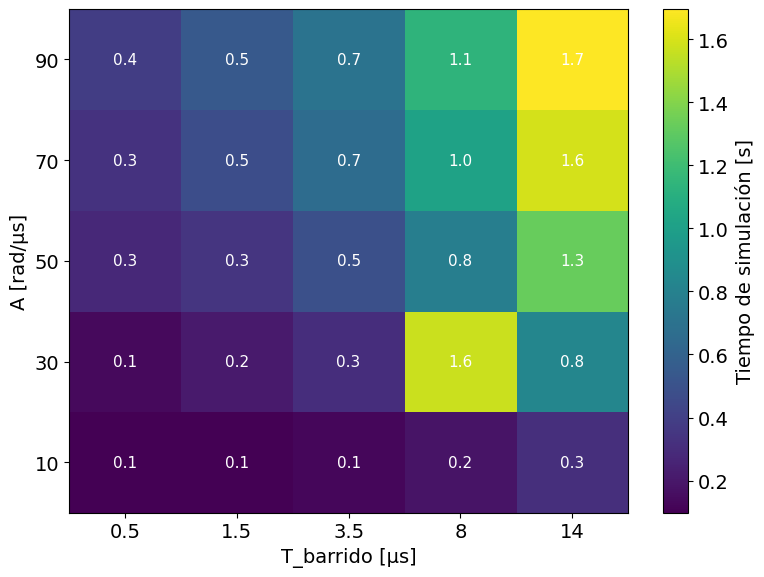

In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt

Q_exacta_func = Q_exacta_func_K13
Q_func        = Q_func_K13
x0_func       = x0_func_K13

A_values = [10, 30, 50, 70, 90]      # ← valores de A
T_values = [0.5, 1.5, 3.5, 8, 14]       # ← valores de T_barrido (k)

tiempos = np.full((len(A_values), len(T_values)), np.nan)

for i, A in enumerate(A_values):
    A_solucion = A
    B = B_solucion = 0.9*A_solucion
    C = C_solucion = 0.1*A_solucion

    # sort_zipped y geometría dependen solo de A → se calculan una vez por fila
    sort_zipped = resolucion_clasica(
        Q_exacta=Q_exacta_func(A_solucion, B_solucion, C_solucion),
        print_resultados=False)
    Q = Q_func(A, B, C)
    geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)

    for j, k in enumerate(T_values):
        t0 = time.time()
        prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                                plot=False, sweep_time=k)
        t_sim = time.time() - t0
        tiempos[i, j] = t_sim
        print(f"A = {A}, T_barrido = {k} µs  →  P(éxito) = {prob*100:.2f}%  "
              f"|  t_simulación = {t_sim:.2f} s")

# ── Mapa de calor ──
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8, 6))
im = plt.imshow(tiempos, origin='lower', aspect='auto')
plt.colorbar(im, label='Tiempo de simulación [s]')

plt.xticks(range(len(T_values)), T_values)
plt.yticks(range(len(A_values)), A_values)
plt.xlabel('T_barrido [µs]')
plt.ylabel('A [rad/µs]')

# Valor numérico en cada celda
for i in range(len(A_values)):
    for j in range(len(T_values)):
        plt.text(j, i, f"{tiempos[i, j]:.1f}",
                 ha='center', va='center', color='w', fontsize=11)

plt.tight_layout()
plt.show()

# Barrido A


===== Grafo P3 =====
  A=  2.00  ->  P_éxito =  76.20%  |  t =  0.04 s
  A=  6.00  ->  P_éxito =  72.00%  |  t =  0.04 s
  A= 10.00  ->  P_éxito =  75.50%  |  t =  0.05 s
  A= 14.00  ->  P_éxito =  75.10%  |  t =  0.05 s
  A= 18.00  ->  P_éxito =  79.10%  |  t =  0.07 s
  A= 22.00  ->  P_éxito =  81.70%  |  t =  0.06 s
  A= 26.00  ->  P_éxito =  79.50%  |  t =  0.07 s
  A= 30.00  ->  P_éxito =  80.30%  |  t =  0.09 s
  A= 34.00  ->  P_éxito =  81.90%  |  t =  0.10 s
  A= 38.00  ->  P_éxito =  80.50%  |  t =  0.10 s
  A= 42.00  ->  P_éxito =  81.20%  |  t =  0.12 s
  A= 46.00  ->  P_éxito =  80.20%  |  t =  0.50 s
  A= 50.00  ->  P_éxito =  81.70%  |  t =  0.12 s
  A= 54.00  ->  P_éxito =  80.90%  |  t =  0.13 s
  A= 58.00  ->  P_éxito =  83.60%  |  t =  0.13 s
  A= 62.00  ->  P_éxito =  84.40%  |  t =  0.16 s
  A= 66.00  ->  P_éxito =  85.90%  |  t =  0.15 s
  A= 70.00  ->  P_éxito =  88.70%  |  t =  0.17 s
  A= 74.00  ->  P_éxito =  86.20%  |  t =  0.17 s
  A= 78.00  ->  P_éxito =  8

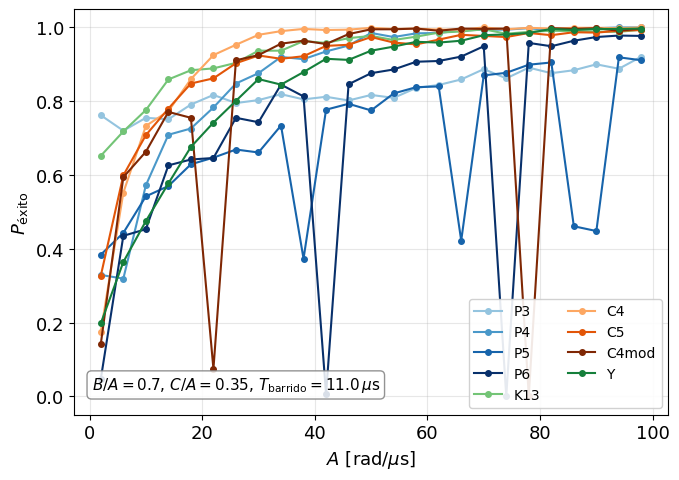

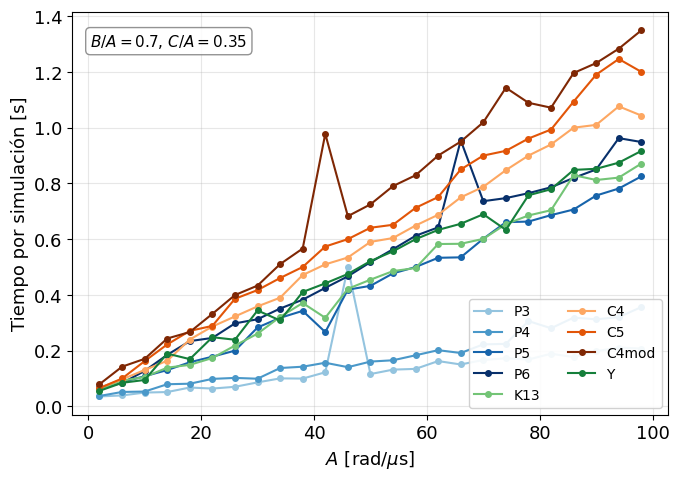

In [33]:
import csv
from pathlib import Path

#### Parámetros ####
ratio_B   = 0.7      # B/A
ratio_C   = 0.35       # C/A
A_values  = np.arange(2, 100, 4)
T_barrido = 11.0       # µs
n_shots   = 1000

CSV_PATH   = Path("barrido_A_results.csv")
RECALCULAR = True   # False -> solo cargar el CSV y graficar (sin volver a simular)

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
    
    "K13":   (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    "Y":  (Q_func_Y,  Q_exacta_func_Y,  x0_func_Y_horizontal),
    
    #"C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),
}


#### Barrido: escribe filas al CSV de forma incremental ####
if RECALCULAR:
    # Cabecera + metadatos. Modo 'w' -> sobrescribe lo anterior.
    with open(CSV_PATH, 'w', newline='', encoding='utf-8') as f:
        f.write(f"# ratio_B={ratio_B}\n")
        f.write(f"# ratio_C={ratio_C}\n")
        f.write(f"# T_barrido={T_barrido}\n")
        f.write(f"# n_shots={n_shots}\n")
        f.write(f"# A_values={list(map(float, A_values))}\n")
        csv.writer(f).writerow(["grafo", "A", "P_exito", "tiempo_s"])   # <-- columna nueva

    t0_total = time.time()
    for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
        print(f"\n===== Grafo {nombre} =====")
        t0_grafo = time.time()
        for A in A_values:
            B = ratio_B * A
            C = ratio_C * A
            Q = Q_func_g(A, B, C)

            # Filtro para evitar casos con detuning no positivo
            if np.any(-np.diag(Q) <= 0):
                prob  = np.nan
                t_sim = np.nan
            else:
                try:
                    sort_zipped = resolucion_clasica(
                        Q_exacta=Q_exacta_func_g(A, B, C),
                        print_resultados=False,
                    )
                    geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func_g)

                    # --- cronómetro: solo la simulación ---
                    t0_sim = time.time()
                    prob, _ = resolver_qubo(
                        Q, geometria, sort_zipped, A, B, C,
                        sweep_time=T_barrido, plot=False, n_shots=n_shots,
                    )
                    t_sim = time.time() - t0_sim
                except Exception:
                    prob  = np.nan
                    t_sim = np.nan

            # Append inmediato -> el CSV refleja el progreso en tiempo real
            with open(CSV_PATH, 'a', newline='', encoding='utf-8') as f:
                csv.writer(f).writerow([
                    nombre, float(A),
                    '' if np.isnan(prob)  else f"{prob:.6f}",
                    '' if np.isnan(t_sim) else f"{t_sim:.4f}",
                ])
            prob_str = 'NaN' if np.isnan(prob)  else f'P_éxito = {prob*100:6.2f}%'
            t_str    = 'NaN' if np.isnan(t_sim) else f't = {t_sim:5.2f} s'
            print(f"  A={float(A):6.2f}  ->  {prob_str}  |  {t_str}")

        print(f"  [{nombre}] tiempo = {time.time()-t0_grafo:.1f} s")
    print(f"\nTiempo total: {time.time()-t0_total:.1f} s")
    print(f"Resultados guardados en: {CSV_PATH.resolve()}")


#### Cargar desde CSV (única fuente de verdad para el gráfico) ####
resultados_A = {}
tiempos_A    = {}
with open(CSV_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('grafo'):
            continue
        partes   = line.split(',')
        nombre   = partes[0]
        A_val    = float(partes[1])
        prob_str = partes[2] if len(partes) > 2 else ''
        t_str    = partes[3] if len(partes) > 3 else ''
        resultados_A[(nombre, A_val)] = float(prob_str) if prob_str else np.nan
        tiempos_A   [(nombre, A_val)] = float(t_str)    if t_str    else np.nan


#### Paleta consistente (misma que en el barrido en T) ####
import matplotlib.cm as cm

familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],
}

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)


#### Gráfico de probabilidad ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    probs = [resultados_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, probs, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.05,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$, $T_\text{{barrido}}={T_barrido}\,\mu$s',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()


#### Gráfico de tiempos ####
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 13})

for nombre in grafos.keys():
    ts = [tiempos_A.get((nombre, float(A)), np.nan) for A in A_values]
    plt.plot(A_values, ts, marker='o', markersize=4, linewidth=1.5,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, ncol=2)
plt.text(0.03, 0.95,
         rf'$B/A={ratio_B}$, $C/A={ratio_C}$',
         transform=plt.gca().transAxes, fontsize=11,
         horizontalalignment='left', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.85))

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# Corregida

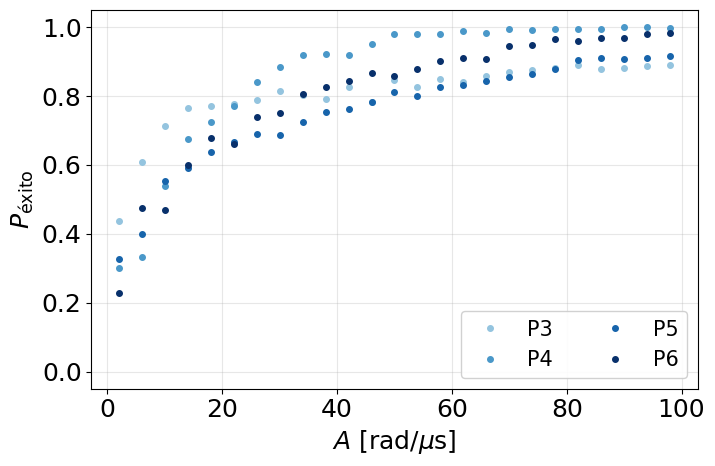

In [53]:
# Actualizado 21/06/2026

# ===================================================================
#  CELDA: grafica el barrido en A
# ===================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------- Datos ----------
A_values = np.array([2, 6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50,
                     54, 58, 62, 66, 70, 74, 78, 82, 86, 90, 94, 98], dtype=float)

datos = {
    'P3':    [0.436, 0.609, 0.712, 0.764, 0.772, 0.776, 0.788, 0.815, 0.803, 0.792,
              0.826, 0.783, 0.847, 0.827, 0.850, 0.840, 0.857, 0.871, 0.876, 0.882,
              0.890, 0.878, 0.881, 0.887, 0.891],
    'P4':    [0.300, 0.334, 0.539, 0.676, 0.724, 0.770, 0.841, 0.884, 0.920, 0.923,
             0.918, 0.950, 0.981, 0.980, 0.981, 0.989, 0.984, 0.995, 0.992, 0.994,
             0.994, 0.996, 1.000, 1.000, 0.999],
    'P5':    [0.327, 0.400, 0.552, 0.591, 0.639, 0.667, 0.690, 0.686, 0.725, 0.754,
             0.763, 0.784, 0.813, 0.801, 0.827, 0.832, 0.843, 0.854, 0.865, 0.878,
             0.904, 0.911, 0.909, 0.912, 0.916],
    'P6':    [0.228, 0.476, 0.469, 0.600, 0.678, 0.660, 0.740, 0.751, 0.805, 0.826,
             0.844, 0.867, 0.859, 0.879, 0.902, 0.911, 0.909, 0.944, 0.949, 0.965,
             0.959, 0.969, 0.969, 0.981, 0.984],
    # 'K13':   [0.493, 0.589, 0.783, 0.854, 0.863, 0.900, 0.923, 0.936, 0.937, 0.955,
    #          0.959, 0.952, 0.975, 0.966, 0.973, 0.981, 0.982, 0.988, 0.984, 0.987,
    #          0.991, 0.991, 0.992, 0.987, 0.993],
    # 'C4':    [0.177, 0.570, 0.727, 0.796, 0.859, 0.928, 0.951, 0.983, 0.988, 0.997,
    #          0.997, 0.995, 0.997, 0.996, 1.000, 0.996, 0.998, 1.000, 0.999, 0.997,
    #          0.995, 0.998, 1.000, 0.999, 0.998],
    # 'C5':    [0.327, 0.583, 0.709, 0.798, 0.819, 0.866, 0.891, 0.896, 0.942, 0.939,
    #          0.933, 0.952, 0.966, 0.967, 0.969, 0.967, 0.987, 0.978, 0.983, 0.986,
    #          0.988, 0.989, 0.990, 0.989, 0.992],
    # 'C4mod': [0.148, 0.576, 0.664, 0.746, 0.769, 0.812, 0.896, 0.917, 0.958, 0.958,
    #          0.955, 0.988, 0.993, 0.992, 0.995, 0.996, 0.999, 0.997, 0.996, 0.000,
    #          0.997, 0.994, 1.000, 0.996, 0.997],
    # 'Y':     [0.184, 0.375, 0.490, 0.554, 0.657, 0.731, 0.807, 0.846, 0.855, 0.890,
    #         0.900, 0.933, 0.950, 0.960, 0.971, 0.981, 0.976, 0.979, 0.989, 0.982,
    #         0.988, 0.993, 0.991, 0.998, 0.994],
}
datos = {k: np.array(v) for k, v in datos.items()}


# ---------- Paleta ----------
nombres = list(datos.keys())
familias = {
    'P': [n for n in nombres if n.startswith('P')],
    'C': [n for n in nombres if n.startswith('C')],
    'K': [n for n in nombres if n.startswith('K')],
    'Y': [n for n in nombres if n == 'Y'],
}
colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in nombres:
    colores['Y'] = cm.Greens(0.8)


# ---------- Gráfico: solo puntos, sin líneas, sin recuadro ----------
plt.figure(figsize=(7.5, 5))
plt.rcParams.update({'font.size': 18})

for nombre in nombres:
    plt.plot(A_values, datos[nombre],
             marker='o', markersize=4, linewidth=0,
             label=nombre, color=colores[nombre])

plt.legend(loc='lower right', fontsize=15, framealpha=0.9, ncol=2)
plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
#plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()

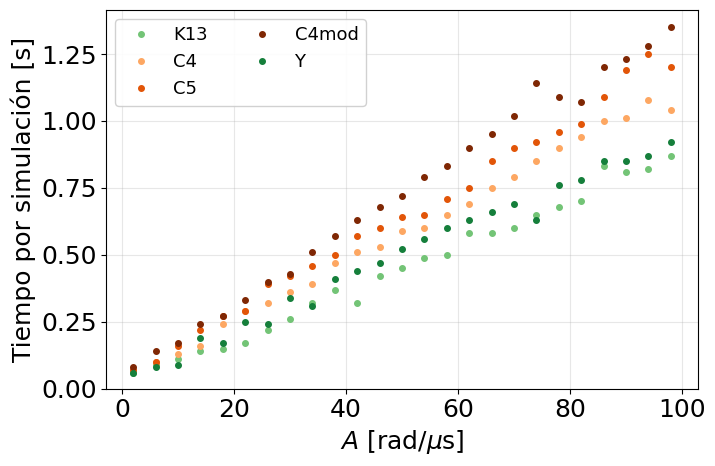

In [46]:
# Actualizado 21/06/2026

# ===================================================================
#  CELDA: grafica los tiempos de simulación del barrido en A
# ===================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

A_values = np.array([2, 6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50,
                     54, 58, 62, 66, 70, 74, 78, 82, 86, 90, 94, 98], dtype=float)

tiempos = {
    # 'P3':    [0.04, 0.04, 0.05, 0.05, 0.07, 0.06, 0.07, 0.09, 0.10, 0.10,
    #           0.12, 0.50, 0.12, 0.13, 0.13, 0.16, 0.15, 0.17, 0.17, 0.17,
    #           0.19, 0.18, 0.20, 0.21, 0.21],
    # 'P4':    [0.04, 0.05, 0.05, 0.08, 0.08, 0.10, 0.10, 0.10, 0.14, 0.14,
    #           0.16, 0.14, 0.16, 0.17, 0.18, 0.20, 0.19, 0.22, 0.22, 0.27,
    #           0.28, 0.32, 0.31, 0.32, 0.36],
    # 'P5':    [0.07, 0.09, 0.11, 0.13, 0.16, 0.18, 0.20, 0.28, 0.32, 0.34,
    #           0.32, 0.42, 0.43, 0.48, 0.50, 0.53, 0.53, 0.60, 0.66, 0.66,
    #           0.69, 0.71, 0.76, 0.78, 0.83],
    # 'P6':    [0.07, 0.08, 0.13, 0.18, 0.23, 0.25, 0.30, 0.31, 0.35, 0.38,
    #           0.43, 0.47, 0.52, 0.56, 0.61, 0.64, 0.68, 0.74, 0.75, 0.76,
    #           0.79, 0.82, 0.85, 0.96, 0.95],
    'K13':   [0.06, 0.09, 0.11, 0.14, 0.15, 0.17, 0.22, 0.26, 0.32, 0.37,
              0.32, 0.42, 0.45, 0.49, 0.50, 0.58, 0.58, 0.60, 0.65, 0.68,
              0.70, 0.83, 0.81, 0.82, 0.87],
    'C4':    [0.07, 0.10, 0.13, 0.16, 0.24, 0.29, 0.32, 0.36, 0.39, 0.47,
              0.51, 0.53, 0.59, 0.60, 0.65, 0.69, 0.75, 0.79, 0.85, 0.90,
              0.94, 1.00, 1.01, 1.08, 1.04],
    'C5':    [0.07, 0.10, 0.16, 0.22, 0.27, 0.29, 0.39, 0.42, 0.46, 0.50,
              0.57, 0.60, 0.64, 0.65, 0.71, 0.75, 0.85, 0.90, 0.92, 0.96,
              0.99, 1.09, 1.19, 1.25, 1.20],
    'C4mod': [0.08, 0.14, 0.17, 0.24, 0.27, 0.33, 0.40, 0.43, 0.51, 0.57,
              0.63, 0.68, 0.72, 0.79, 0.83, 0.90, 0.95, 1.02, 1.14, 1.09,
              1.07, 1.20, 1.23, 1.28, 1.35],
    'Y':     [0.06, 0.08, 0.09, 0.19, 0.17, 0.25, 0.24, 0.34, 0.31, 0.41,
              0.44, 0.47, 0.52, 0.56, 0.60, 0.63, 0.66, 0.69, 0.63, 0.76,
              0.78, 0.85, 0.85, 0.87, 0.92],
}
tiempos = {k: np.array(v) for k, v in tiempos.items()}


# ---------- Paleta (idéntica a la de P_éxito) ----------
nombres = list(tiempos.keys())
familias = {
    'P': [n for n in nombres if n.startswith('P')],
    'C': [n for n in nombres if n.startswith('C')],
    'K': [n for n in nombres if n.startswith('K')],
    'Y': [n for n in nombres if n == 'Y'],
}
colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.4 + 0.6 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for n in familias['K']:
    colores[n] = cm.Greens(0.5)
if 'Y' in nombres:
    colores['Y'] = cm.Greens(0.8)


# ---------- Gráfico ----------
plt.figure(figsize=(7.5, 5))
plt.rcParams.update({'font.size': 18})

for nombre in nombres:
    plt.plot(A_values, tiempos[nombre],
             marker='o', markersize=4, linewidth=0,
             label=nombre, color=colores[nombre])

plt.legend(loc='upper left', fontsize=13, framealpha=0.9, ncol=2)
plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'Tiempo por simulación [s]')
plt.grid(alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# $T_{barrido}$


=== El grafo K13 ha tardado en ejecutarse 29.05 segundos ===

=== El grafo C4 ha tardado en ejecutarse 41.30 segundos ===

=== El grafo C5 ha tardado en ejecutarse 38.14 segundos ===

=== El grafo C4mod ha tardado en ejecutarse 47.84 segundos ===

=== El grafo Y ha tardado en ejecutarse 38.66 segundos ===

  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))
  Grafo           P_inf         β (1/µs)         R²        RSS  dof
  ──────────────────────────────────────────────────────────────
  K13        0.9771±0.0040  46.59±1.25      0.9724     0.0168  38
  C4         1.0008±0.0090  34.32±1.67      0.9394     0.0721  38
  C5         0.9706±0.0159  28.40±2.23      0.8863     0.1909  38
  C4mod      0.9961±0.0116  32.62±1.98      0.9164     0.1139  38
  Y          0.9887±0.0221  12.91±0.79      0.9641     0.0885  38

Parámetros: A=50, B/A=0.7, C/A=0.35, T=[0.013, 0.247] µs, step=0.006 µs, n_rep=4


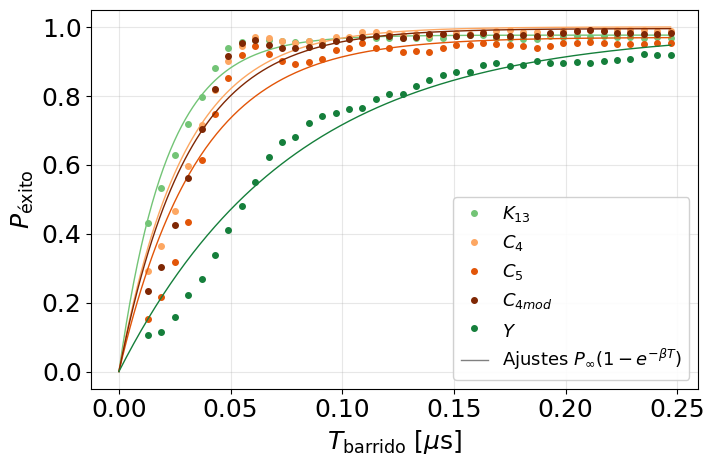

In [64]:
# Barrido en T_barrido para varios grafos
# Mantenemos A, B/A, C/A fijos en los valores de trabajo
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

A = 50
# ratio_B = 0.7
# ratio_C = 0.35
ratio_B = 0.7
ratio_C = 0.35
B = ratio_B * A
C = ratio_C * A

T_values = np.arange(0.013, 0.25, 0.006)  # 1, 3, 5, ..., 29 µs
# T_values = np.arange(0.004, 0.12, 0.003)  # 1, 3, 5, ..., 29 µs

n_repeticiones = 4

resultados_T = {} 
tiempos_T = {}   

grafos = {
    # "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    # "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    # "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    # "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    "K13": (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod": (Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),

    #"C5mod": (Q_func_C5mod, Q_exacta_func_C5mod, x0_func_C5mod),

#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),
#    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9)
}

for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()

    Q = Q_func_g(A, B, C)
    Q_exacta = Q_exacta_func_g(A, B, C)

    diag = -np.diag(Q)
    if np.any(diag <= 0):
        print(f"  {nombre}: detuning <=0 con A={A}, B={B}, C={C}. Se omite.")
        continue

    sort_zipped = resolucion_clasica(Q_exacta)

    for T in T_values:
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=T,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  T={T}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)

        resultados_T[(nombre, T)] = probs
        tiempos_T[(nombre, T)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


# ===================================================================
#  Cálculo de medias
# ===================================================================
medias_T = {}
for nombre in grafos.keys():
    medias_T[nombre] = np.array([np.nanmean(resultados_T[(nombre, T)]) for T in T_values])


# ===================================================================
#  AJUSTE LANDAU-ZENER:  P(T) = P_inf * (1 - exp(-beta * T))
# ===================================================================

def modelo_LZ_T(T, P_inf, beta):
    """P(T) = P_inf * (1 - exp(-beta * T))"""
    return P_inf * (1.0 - np.exp(-beta * T))

def ajustar_LZ_T(T_vals, P_vals):
    """Ajusta modelo_LZ_T y devuelve (popt, perr, R2, RSS, dof)."""
    mask = ~np.isnan(P_vals)
    T_clean = np.array(T_vals)[mask]
    P_clean = np.array(P_vals)[mask]
    
    popt, pcov = curve_fit(modelo_LZ_T, T_clean, P_clean, p0=(0.9, 50.0), maxfev=10000,
                           bounds=([0, 0], [1.05, np.inf]))
    perr = np.sqrt(np.diag(pcov))
    P_pred = modelo_LZ_T(T_clean, *popt)
    residuos = P_clean - P_pred
    RSS = np.sum(residuos**2)
    SS_tot = np.sum((P_clean - np.mean(P_clean))**2)
    R2 = 1.0 - RSS / SS_tot if SS_tot != 0 else 0
    dof = len(T_clean) - len(popt)
    return popt, perr, R2, RSS, dof

print("\n" + "="*70)
print("  AJUSTE: P(T) = P_inf · (1 - exp(-β·T))")
print("="*70)
print(f"  {'Grafo':<10} {'P_inf':>10} {'β (1/µs)':>16} {'R²':>10} {'RSS':>10}  dof")
print(f"  {'─'*62}")

ajustes_T = {}
for nombre in grafos.keys():
    popt, perr, R2, RSS, dof = ajustar_LZ_T(T_values, medias_T[nombre])
    ajustes_T[nombre] = {'popt': popt, 'perr': perr, 'R2': R2, 'RSS': RSS, 'dof': dof}
    print(f"  {nombre:<10} {popt[0]:.4f}±{perr[0]:.4f}"
          f"  {popt[1]:.2f}±{perr[1]:.2f}"
          f"  {R2:10.4f} {RSS:10.4f}  {dof}")


# ===================================================================
#  Gráfica
# ===================================================================

familias = {
    'P': [n for n in grafos if n.startswith('P')],
    'C': [n for n in grafos if n.startswith('C')],
    'K': [n for n in grafos if n.startswith('K')],
    'Y': [n for n in grafos if n.startswith('Y')],  
}


# colores_Pn = {
#     'P3': '#7ec8e3',  # azul claro
#     'P4': '#3a86ff',  # azul medio
#     'P5': '#1b4965',  # azul oscuro
#     'P6': '#0b132b',  # casi negro-azul
# }

colores = {}
for i, n in enumerate(familias['P']):
    colores[n] = cm.Blues(0.35 + 0.8 * i / max(len(familias['P']) - 1, 1))
# for n in familias['P']:
#     # colores[n] = colores_Pn.get(n, 'blue')
#     colores[n] = cm.Blues(0.25 + 0.75 * i / max(len(familias['P']) - 1, 1))
for i, n in enumerate(familias['C']):
    colores[n] = cm.Oranges(0.4 + 0.6 * i / max(len(familias['C']) - 1, 1))
for i, n in enumerate(familias['K']):
    colores[n] = cm.Greens(0.5)
if 'Y' in grafos:
    colores['Y'] = cm.Greens(0.8)

plt.figure(figsize=(7.5, 5))
plt.rcParams.update({'font.size': 18})

T_fine = np.linspace(0, max(T_values), 300)

for nombre in grafos.keys():
    medias = medias_T[nombre]
    popt = ajustes_T[nombre]['popt']
    
    # plt.plot(T_values, medias, 'o', markersize=4, color=colores[nombre])
    # plt.plot(T_fine, modelo_LZ_T(T_fine, *popt), '-', linewidth=1,
    #          label=nombre, color=colores[nombre])
    plt.plot(T_values, medias, 'o', markersize=4, color=colores[nombre],
             label=rf'${nombre[0]}_{{{nombre[1:]}}}$')
    plt.plot(T_fine, modelo_LZ_T(T_fine, *popt), '-', linewidth=1,
             color=colores[nombre])

plt.plot([], [], '-', color='gray', linewidth=1, label=r'Ajustes $P_\infty(1-e^{-\beta T})$')
# plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.legend(loc='lower right', fontsize=13, framealpha=0.9, handlelength=1.5)


plt.xlabel(r'$T_\text{barrido}$ [$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
#plt.savefig("barrido_T.png", dpi=200, bbox_inches='tight')
print(f"\nParámetros: A={A}, B/A={ratio_B}, C/A={ratio_C}, "
      f"T=[{T_values[0]:.3f}, {T_values[-1]:.3f}] µs, step={T_values[1]-T_values[0]:.3f} µs, "
      f"n_rep={n_repeticiones}")
plt.show()


# Heatmap

---Solución clásica: 
 [('01010', np.float64(-210.0)), ('10100', np.float64(-210.0)), ('01011', np.float64(-177.5)), ('10101', np.float64(-177.5)), ('00101', np.float64(-175.0)), ('01001', np.float64(-175.0))] 



C:\Users\javip\AppData\Local\Temp\ipykernel_25924\1829515355.py:146: RuntimeWarning: invalid value encountered in divide
  escalas     = (delta_local / delta_end).tolist()


A=50: 89.08 s


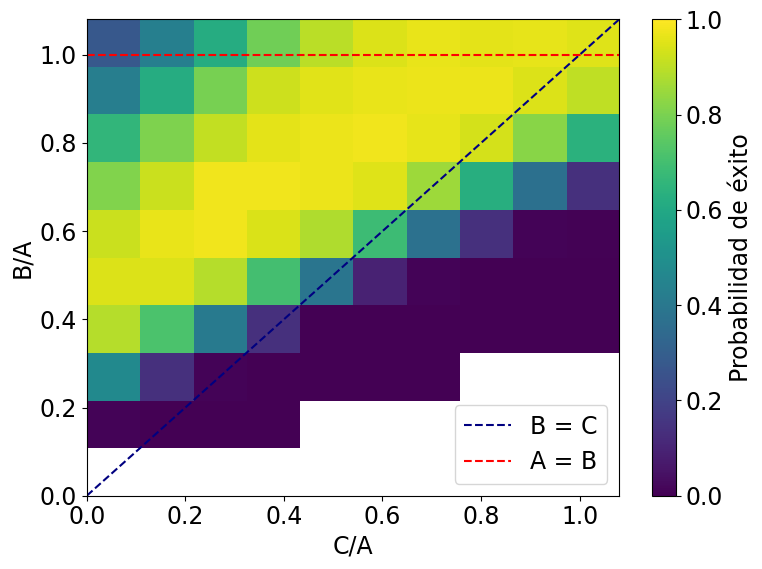

In [9]:
A = A_solucion =50 #10
B = B_solucion =0.7*A_solucion#0.5*A
C = C_solucion =0.35*A_solucion#0.8*B
x0_func=x0_func_C4mod
Q_func = Q_func_C4mod
Q_exacta_func = Q_exacta_func_C4mod

# sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)


sort_zipped = resolucion_clasica(Q_exacta = Q_func(A_solucion, B_solucion, C_solucion), print_resultados=True)


A_values = [50]


resultados = {}

for A in A_values:

    # paso = 0.03
    # paso = 0.08
    paso = 0.12

    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            # if np.any(diag <= -0.5):
            if np.any(diag <= -1):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=1300)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan




    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución


    plt.rcParams.update({'font.size': 17})
    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    #plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='A = B')

    #plt.figtext(0.5, -0.02,
    #        f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
    #        ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()


===== Grafo C4mod =====
---Solución clásica: 
 [('00101', np.float64(-140.0)), ('01001', np.float64(-140.0)), ('01010', np.float64(-140.0)), ('10100', np.float64(-140.0)), ('10010', np.float64(-125.0)), ('00010', np.float64(-122.5))] 



C:\Users\javip\AppData\Local\Temp\ipykernel_25924\1829515355.py:146: RuntimeWarning: invalid value encountered in divide
  escalas     = (delta_local / delta_end).tolist()


A=50: 1324.54 s


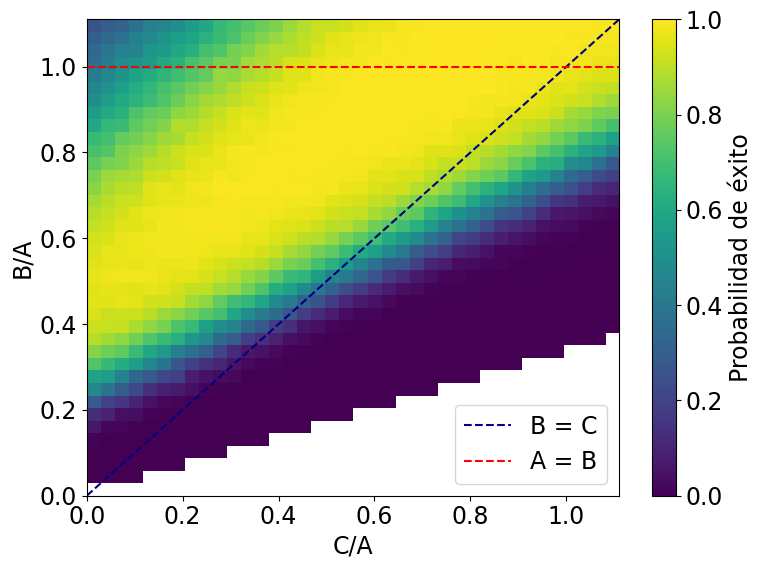

In [19]:
# Listado de grafos sobre los que se generan los heatmaps
grafos = {
    # "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    # "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    # "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
    # "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),

    # "K13":  (Q_func_K13, Q_exacta_func_K13, x0_func_K13),
    # "C4":   (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    # "C5":   (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C4mod":(Q_func_C4mod, Q_exacta_func_C4mod, x0_func_C4mod),
    # "Y":    (Q_func_Y,  Q_exacta_func_Y,  x0_func_Y_horizontal),

    # "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
    # "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),
}


A = A_solucion =50 #10
B = B_solucion =0.7*A_solucion#0.5*A
C = C_solucion =0.35*A_solucion#0.8*B

for nombre_grafo, (Q_func, Q_exacta_func, x0_func) in grafos.items():
    print(f"\n===== Grafo {nombre_grafo} =====")

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)
    # sort_zipped = resolucion_clasica(Q_exacta = Q_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    A_values = [50]

    resultados = {}

    for A in A_values:

        # paso = 0.12
        paso = 0.03

        B_values = np.arange(0*A, 1.12*A, paso*A)
        C_values = np.arange(0*A, 1.12*A, paso*A)

        t0 = time.time() # Para medir el tiempo de ejecución

        for B in B_values:
            for C in C_values:
                Q = Q_func(A, B, C)
                diag = -np.diag(Q)

                # Filtro para evitar casoscon detuning negativo
                if np.any(diag <= -1):
                    resultados[(A, B, C)] = np.nan
                    continue
                try:
                    geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                    prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=1300)
                    resultados[(A, B, C)] = prob
                except Exception:
                    # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                    # se asigna NaN y el barrido continúa con el siguiente punto.
                    resultados[(A, B, C)] = np.nan




        B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
        C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
        malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
        malla_masked = np.ma.masked_invalid(malla)

        # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
        B_norm = [b / A for b in B_unique]
        C_norm = [c / A for c in C_unique] 

        print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

        plt.rcParams.update({'font.size': 17})
        plt.figure(figsize=(8, 6))
        plt.imshow(malla_masked, origin='lower', aspect='auto',
                   extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
                   vmin=0, vmax=1)
        plt.colorbar(label='Probabilidad de éxito')
        plt.xlabel('C/A')
        plt.ylabel('B/A')
        #plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

        # Línea B = C (en unidades normalizadas B/A = C/A)
        x_line = np.linspace(C_norm[0], C_norm[-1], 100)
        plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
        plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='A = B')
        #plt.figtext(0.5, -0.02,
        #        f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
        #        ha='center', fontsize=9, style='italic')
        plt.legend()
        #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

        plt.tight_layout()
        plt.show()